ADF p-value: 0.0000


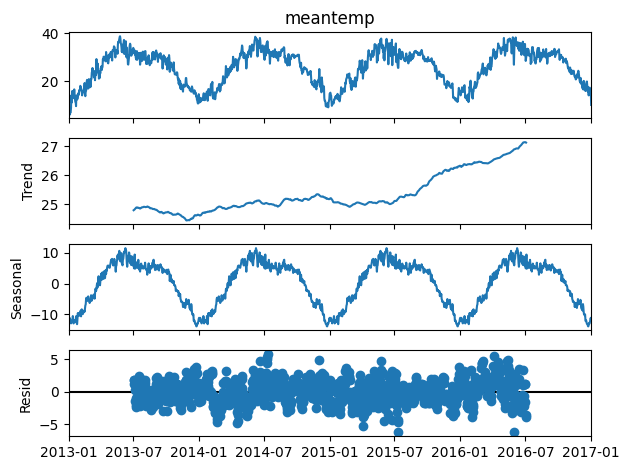

In [4]:
%pip install pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error

df = pd.read_csv('DailyDelhiClimateTrain.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
ts = df['meantemp']

result = adfuller(ts.diff().dropna())
print(f'ADF p-value: {result[1]:.4f}')

decomp = seasonal_decompose(ts, model='additive', period=365)
decomp.plot()
plt.tight_layout()
plt.show()

In [ ]:
train = ts[:'2016-12-31']
# Define the forecast horizon for one year (365 days)
forecast_horizon = 365

model = auto_arima(train, seasonal=True, m=365,
                   start_p=1, start_q=1, max_p=2, max_q=2,
                   trace=True, suppress_warnings=True) # Changed trace to True
model.fit(train)

# Generate a forecast for the specified horizon
forecast = model.predict(n_periods=forecast_horizon)

# Align the actual 'test' data to the forecast index for a fair comparison
test_aligned = ts.loc[forecast.index]

plt.plot(train, label='Train', color='steelblue')
plt.plot(test_aligned, label='Actual (Forecast Period)', color='red')
plt.plot(forecast, label='Forecast', color='green', linestyle='--')
plt.legend()
plt.title('Delhi Temperature Forecast (1-Year Horizon)')
plt.show()

# Calculate RMSE only for the forecasted period
print(f'RMSE: {np.sqrt(mean_squared_error(test_aligned, forecast)):.2f}')

Performing stepwise search to minimize aic
